In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

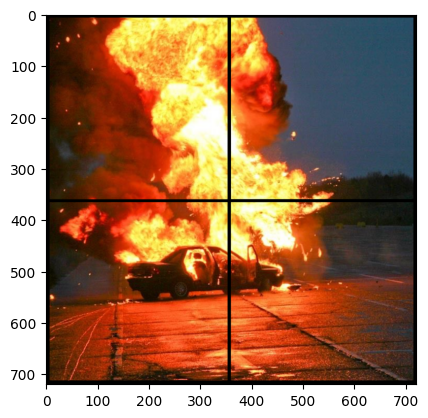

In [15]:
Meledak = plt.imread('Assets/Meledak.png')
plt.imshow(Meledak)
plt.show()

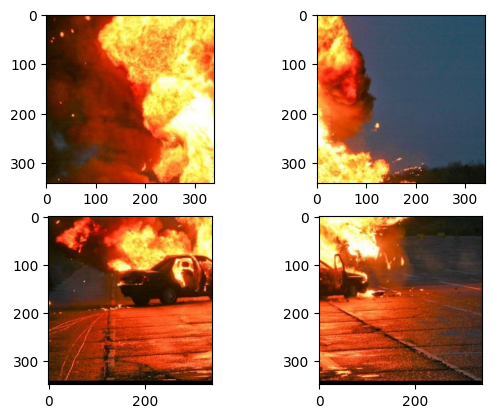

In [16]:
crop1 = Meledak[10:350, 10:350]
crop2 = Meledak[10:350, 360:700]
crop3 = Meledak[370:720, 10:350]
crop4 = Meledak[370:720, 360:700]

plt.subplot(2, 2, 1)
plt.imshow(crop1, cmap='gray')

plt.subplot(2, 2, 2)
plt.imshow(crop2, cmap='gray')

plt.subplot(2, 2, 3)
plt.imshow(crop3, cmap='gray')

plt.subplot(2, 2, 4)
plt.imshow(crop4, cmap='gray')

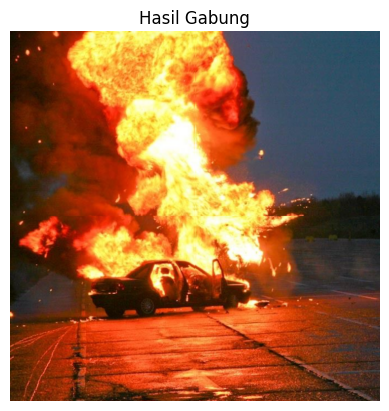

In [20]:
h, w, c = crop1.shape

reconstruct = np.zeros((h*2, w*2, c))

for i in range(h):
    for j in range(w):
       
        reconstruct[i, j] = crop1[i, j]
        reconstruct[i, j + w] = crop2[i, j]
        reconstruct[i + h, j] = crop3[i, j]
        reconstruct[i + h, j + w] = crop4[i, j]

plt.imshow(reconstruct)
plt.title("Hasil Gabung")
plt.axis('off')
plt.show()

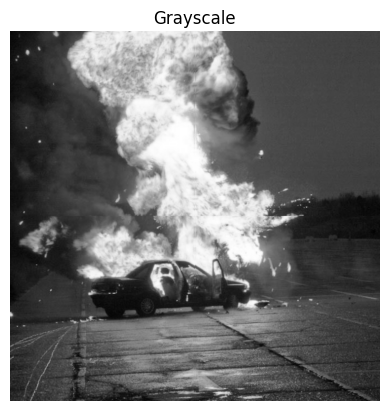

In [ ]:
h, w, c = reconstruct.shape
gray = np.zeros((h, w))

for i in range(h):
    for j in range(w):
        r, g, b = reconstruct[i, j]
        gray[i, j] = 0.299*r + 0.587*g + 0.114*b

gray = gray * 255
gray = np.round(gray)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

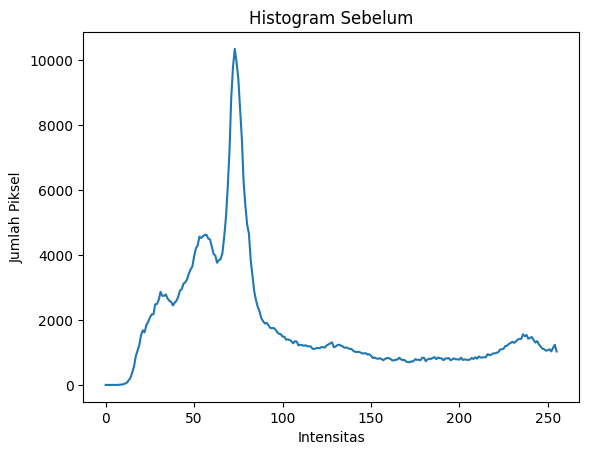

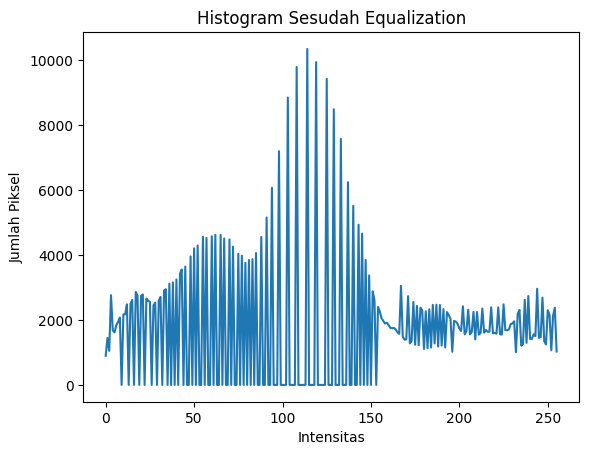

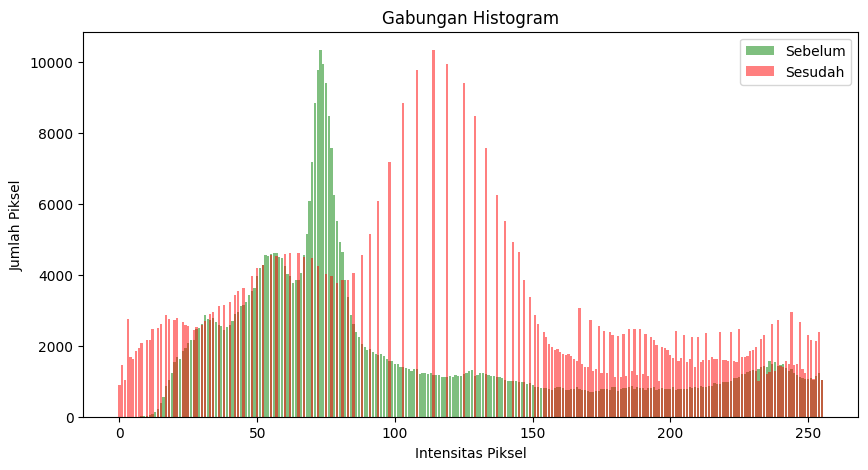

In [30]:
h, w, c = reconstruct.shape
gray = np.zeros((h, w))

for i in range(h):
    for j in range(w):
        r, g, b = reconstruct[i, j]   
        gray[i, j] = 0.299*r + 0.587*g + 0.114*b

gray = gray * 255
gray = np.round(gray)

hist = np.zeros(256)

for i in range(h):
    for j in range(w):
        hist[int(gray[i, j])] += 1

plt.figure()
plt.plot(hist)
plt.title("Histogram Sebelum")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")
plt.show()

cdf = np.zeros(256)
cdf[0] = hist[0]

for i in range(1, 256):
    cdf[i] = cdf[i-1] + hist[i]

cdf_min = 0
for i in range(256):
    if cdf[i] != 0:
        cdf_min = cdf[i]
        break

cdf_norm = np.zeros(256)
total = h * w

for i in range(256):
    cdf_norm[i] = (cdf[i] - cdf_min) / (total - cdf_min) * 255

equal = np.zeros((h, w))

for i in range(h):
    for j in range(w):
        val = int(gray[i, j])
        equal[i, j] = cdf_norm[val]

equal = np.round(equal)

hist_after = np.zeros(256)

for i in range(h):
    for j in range(w):
        hist_after[int(equal[i, j])] += 1

plt.figure()
plt.plot(hist_after)
plt.title("Histogram Sesudah Equalization")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")
plt.show()

x = np.arange(256)

plt.figure(figsize=(10,5))

plt.bar(x, hist, color='green', alpha=0.5, label='Sebelum')
plt.bar(x, hist_after, color='red', alpha=0.5, label='Sesudah')

plt.title("Gabungan Histogram")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.legend()

plt.show()

In [ ]:
def spesifikasi_histogram(citra_asal, citra_target):

    height, width = citra_asal.shape

    hist_asal = [0] * 256
    hist_target = [0] * 256

    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):

            pixel = int(citra_asal[i][j])

            hist_asal[pixel] += 1

    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):

            pixel = int(citra_target[i][j])

            hist_target[pixel] += 1

    cdf_asal = [0] * 256
    cdf_target = [0] * 256

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):

        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]

        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    cdf_asal = np.array(cdf_asal) / cdf_asal[-1]
    cdf_target = np.array(cdf_target) / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):

        selisih = np.abs(cdf_target - cdf_asal[i])

        map_hist[i] = np.argmin(selisih)

    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):

            pixel_lama = citra_asal[i][j]

            hasil[i][j] = map_hist[pixel_lama]

    return hasil

(720, 720)


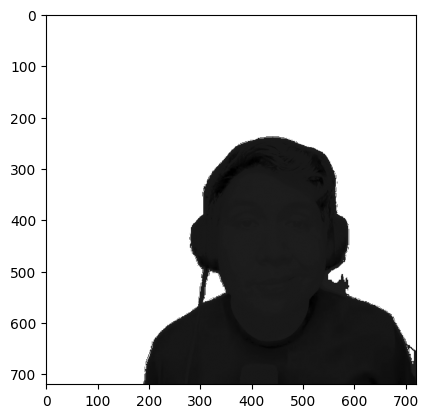

In [25]:
windut = cv2.imread('Assets/Windut.png')
bunga = cv2.imread('Assets/Bunga.png')

windut_gray = cv2.cvtColor(windut, cv2.COLOR_BGR2GRAY)
bunga_gray = cv2.cvtColor(bunga, cv2.COLOR_BGR2GRAY)

windut_sp = spesifikasi_histogram(windut_gray, bunga_gray)

plt.imshow(windut_sp, cmap='gray')
print(windut_sp.shape)